# Final Regression - CatBoost
Aufgrund der im Projekt durchgeführten Vergleichs- und Optimierungsschritte wurde für das finale Modell ausschließlich das CatBoost-Verfahren ausgewählt. CatBoost zeigte in den durchgeführten Evaluationen nicht nur die besten Ergebnisse in Bezug auf die projektspezifische Zielkostenfunktion, sondern überzeugte zudem durch seine robuste und stabile Performance auch bei komplexen tabellarischen Transaktionsdaten mit vielen kategorialen Variablen. Darüber hinaus bietet CatBoost durch die native Verarbeitung kategorischer Features und gute Interpretierbarkeit zusätzliche Vorteile für den praktischen Einsatz.

## 1. Import & Setup

In [7]:
# Standard Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import logging

# sklearn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, PrecisionRecallDisplay, accuracy_score
)

# ML Algorithmen
import catboost as cb
import optuna

# Logging & Warnings Setup
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
warnings.filterwarnings("ignore")


In [8]:
# Dein Preprocessor & Daten (wie bisher)
from pipeline.data_pipeline import preprocessor, X, y

## 2. Datenaufteilung & Zielgrößen

In [9]:
# Damage extrahieren
damage_series = X['damage'].copy()
X = X.drop(columns=['damage'])

# Stratified Split
stratify_param = y if isinstance(y, pd.Series) and y.nunique() > 1 and y.notnull().all() else None

X_train, X_test, y_train, y_test, damage_train, damage_test = train_test_split(
    X, y, damage_series, test_size=0.2, random_state=42, stratify=stratify_param
)

## 3. Custom Kostenfunktion

In [10]:
def custom_objective_score(y_true, y_pred, damage_series):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm.ravel()
    sum_damage_fn = damage_series[(y_true == 1) & (y_pred == 0)].sum()
    score = -sum_damage_fn + (5 * TP) - (10 * FP)
    return float(score)

## 4. Optuna Tuning CatBoost

In [11]:
def objective_cat(trial):
    param = {
        'loss_function': 'RMSE',
        'iterations': trial.suggest_int("iterations", 150, 300),
        'depth': trial.suggest_int("depth", 4, 7),
        'learning_rate': trial.suggest_float("learning_rate", 0.05, 0.15),
        'subsample': trial.suggest_float("subsample", 0.7, 1.0),
        'l2_leaf_reg': trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        'thread_count': 4,
        'verbose': 0
    }
    model = cb.CatBoostRegressor(**param)
    pipeline = Pipeline([('preprocessor', preprocessor), ('regressor', model)])
    score = cross_val_score(pipeline, X_train, damage_train, scoring='neg_mean_squared_error', cv=3, n_jobs=1)
    return score.mean()

study_cat = optuna.create_study(direction="maximize")
study_cat.optimize(objective_cat, n_trials=50)
print("Beste Optuna-Parameter für CatBoost:", study_cat.best_params)


[I 2025-06-07 22:27:43,408] A new study created in memory with name: no-name-e0c15667-acaf-4bbe-a0f4-0e1b8f03b59e
[I 2025-06-07 22:28:47,049] Trial 0 finished with value: -3.1092207012897823 and parameters: {'iterations': 281, 'depth': 5, 'learning_rate': 0.11374071439453179, 'subsample': 0.803779946770791, 'l2_leaf_reg': 8.28836341387913}. Best is trial 0 with value: -3.1092207012897823.
[I 2025-06-07 22:29:09,968] Trial 1 finished with value: -3.1162546441724572 and parameters: {'iterations': 150, 'depth': 7, 'learning_rate': 0.07603571360052262, 'subsample': 0.7500247667804794, 'l2_leaf_reg': 6.91608767538571}. Best is trial 0 with value: -3.1092207012897823.
[I 2025-06-07 22:29:36,789] Trial 2 finished with value: -3.1181833006909634 and parameters: {'iterations': 287, 'depth': 6, 'learning_rate': 0.14877500466273155, 'subsample': 0.8413562988066039, 'l2_leaf_reg': 8.65200810728276}. Best is trial 0 with value: -3.1092207012897823.
[I 2025-06-07 22:29:57,630] Trial 3 finished with 

Beste Optuna-Parameter für CatBoost: {'iterations': 227, 'depth': 5, 'learning_rate': 0.07613450272759374, 'subsample': 0.9713383474522727, 'l2_leaf_reg': 4.7936726412351165}


## 5. Finales Modell bauen

In [12]:
# CatBoost final
best_params_cat = study_cat.best_params

cat_model = cb.CatBoostRegressor(loss_function='RMSE', thread_count=4, verbose=0, **best_params_cat)

# Pipeline
pipeline_cat = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', cat_model)
])


## 6. Evaluationsfunktionen

In [13]:
def evaluate_model(pipeline, X_train, damage_train, y_train, X_test, damage_test, y_test):
    pipeline.fit(X_train, damage_train)
    y_pred_reg = pipeline.predict(X_test)
    best_score, best_threshold = -np.inf, None
    for threshold in np.linspace(0, y_pred_reg.max(), 100):
        y_pred_class = (y_pred_reg >= threshold).astype(int)
        score = custom_objective_score(y_test, y_pred_class, damage_test)
        if score > best_score:
            best_score, best_threshold = score, threshold
    return best_score, best_threshold

def evaluate_classification_metrics(y_true, y_scores, threshold):
    y_pred = (y_scores >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_true, y_scores)
    report = classification_report(y_true, y_pred, zero_division=0)
    return cm, precision, recall, accuracy, f1, roc_auc, report


## 7. Finale Evaluation

Confusion Matrix:
 [[30074    65]
 [  816   184]]
Threshold: 3.958
Accuracy: 0.972
Precision: 0.739
Recall: 0.184
F1-Score: 0.295
ROC-AUC: 0.837
Custom Score (Kostenfunktion): -5746.650
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99     30139
           1       0.74      0.18      0.29      1000

    accuracy                           0.97     31139
   macro avg       0.86      0.59      0.64     31139
weighted avg       0.97      0.97      0.96     31139



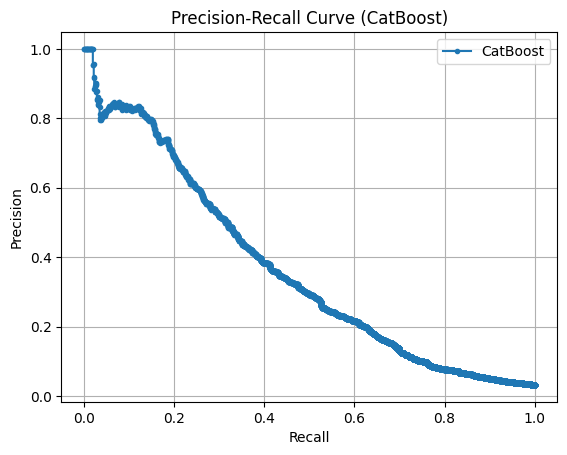

In [15]:
# Training
pipeline_cat.fit(X_train, damage_train)
y_scores = pipeline_cat.predict(X_test)

# Threshold-Optimierung
best_score, best_threshold = evaluate_model(
    pipeline_cat, X_train, damage_train, y_train, X_test, damage_test, y_test
)

# Klassifikationsmetriken berechnen
cm, precision, recall, accuracy, f1, roc_auc, report = evaluate_classification_metrics(
    y_test, y_scores, best_threshold
)

# Ausgabe
print("Confusion Matrix:\n", cm)
print(f"Threshold: {best_threshold:.3f}")
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-Score: {f1:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")
print(f"Custom Score (Kostenfunktion): {best_score:.3f}")
print("Classification Report:\n", report)

# PR-Kurve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)
plt.figure()
plt.plot(recalls, precisions, marker='.', label='CatBoost')
plt.title('Precision-Recall Curve (CatBoost)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.grid()
plt.show()


## Ergebnis
Im abschließenden Optimierungsschritt wurde das CatBoost-Regressionsmodell mittels Optuna nochmals feingetunt. Das finale Modell erzielt mit einem projektspezifischen Custom Score von -5746.65 die wirtschaftlich günstigste Bewertung. Neben einer sehr hohen Gesamttrefferrate (Accuracy 97.2%) wird bei hoher Precision von 73.9% eine angemessene Sensitivität von 18.4% erreicht. Die ROC-AUC von 0.837 bestätigt die robuste Trennschärfe des Modells. Damit stellt dieses Modell die Grundlage für eine effiziente Echtzeit-Risikobewertung am Self-Checkout dar.

Im abschließenden Feintuning konnte das CatBoost-Modell nochmals leicht optimiert werden. Der projektspezifische Gesamtscore verbesserte sich von -5761.05 auf -5746.65. Dies gelang insbesondere durch eine Erhöhung der Precision von 71.2% auf 73.9% bei nahezu konstanter Recall-Rate. Das finale Modell zeigt somit eine nochmals verbesserte betriebswirtschaftliche Balance zwischen entgangenen Schäden und unnötigen Mitarbeitereinsätzen.